# Stock Price Forecasting Using ARIMA

## Coding Samurai Internship – Data Science

### Project Overview
This project focuses on analyzing historical stock price data and forecasting future stock prices using a time series forecasting model.

### Objectives
- Load and understand historical stock price data
- Perform data cleaning and preprocessing
- Analyze stock price trends
- Build an ARIMA time series forecasting model
- Forecast future stock prices
- Evaluate the model performance
- Visualize actual and predicted prices

### Technologies Used
- Python
- Pandas
- NumPy
- Matplotlib
- Statsmodels
- Scikit-learn

In [2]:
!pip install statsmodels


'C:\Users\USER\AppData\Local\Programs\Python\Python310\Scripts\pip.exe' was blocked by your organization's Device Guard policy.
Contact your support person for more info.


In [6]:
import sys
print(sys.executable)

c:\Users\USER\AppData\Local\Programs\Python\Python310\python.exe


In [9]:
import sys
!{sys.executable} -m pip install statsmodels

You should consider upgrading via the 'c:\Users\USER\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [10]:
import sys
print(sys.executable)

c:\Users\USER\AppData\Local\Programs\Python\Python310\python.exe


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [13]:
!pip install yfinance

'C:\Users\USER\AppData\Local\Programs\Python\Python310\Scripts\pip.exe' was blocked by your organization's Device Guard policy.
Contact your support person for more info.


In [14]:
import yfinance as yf

stock = yf.download(
    "AAPL",
    start="2020-01-01",
    end="2025-01-01",
    auto_adjust=False
)

stock.head()

ModuleNotFoundError: No module named 'yfinance'

In [15]:
print("Dataset Shape:", stock.shape)

print("\nDataset Information:")
stock.info()

print("\nMissing Values:")
print(stock.isnull().sum())

print("\nStatistical Summary:")
display(stock.describe())

NameError: name 'stock' is not defined

In [16]:
import yfinance as yf

stock = yf.download(
    "AAPL",
    start="2020-01-01",
    end="2025-01-01",
    auto_adjust=False
)

print("Stock data downloaded successfully!")
display(stock.head())

ModuleNotFoundError: No module named 'yfinance'

In [17]:
import sys
!{sys.executable} -m pip install yfinance

     ------------------------------------ 144.1/144.1 KB 778.0 kB/s eta 0:00:00
     -------------------------------------- 179.5/179.5 KB 1.8 MB/s eta 0:00:00
     -------------------------------------- 180.2/180.2 KB 1.8 MB/s eta 0:00:00
     ---------------------------------------- 2.0/2.0 MB 3.0 MB/s eta 0:00:00
     -------------------------------------- 109.9/109.9 KB 2.1 MB/s eta 0:00:00
     -------------------------------------- 185.1/185.1 KB 2.2 MB/s eta 0:00:00
  Using cached pycparser-3.0-py3-none-any.whl (48 kB)


You should consider upgrading via the 'c:\Users\USER\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [18]:
import yfinance as yf

stock = yf.download(
    "AAPL",
    start="2020-01-01",
    end="2025-01-01",
    auto_adjust=False
)

print("Stock data downloaded successfully!")
display(stock.head())

[*********************100%***********************]  1 of 1 completed

Stock data downloaded successfully!


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,,
2020-01-02,72.271523,75.087502,75.150002,73.797501,74.059998,135480400
2020-01-03,71.568924,74.357498,75.144997,74.125000,74.287498,146322800
2020-01-06,72.139191,74.949997,74.989998,73.187500,73.447502,118387200
2020-01-07,71.799919,74.597504,75.224998,74.370003,74.959999,108872000
2020-01-08,72.954933,75.797501,76.110001,74.290001,74.290001,132079200


In [19]:
print("Dataset Shape:", stock.shape)

print("\nDataset Information:")
stock.info()

print("\nMissing Values:")
print(stock.isnull().sum())

print("\nStatistical Summary:")
display(stock.describe())

Dataset Shape: (1258, 6)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1258 entries, 2020-01-02 to 2024-12-31
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Adj Close, AAPL)  1258 non-null   float64
 1   (Close, AAPL)      1258 non-null   float64
 2   (High, AAPL)       1258 non-null   float64
 3   (Low, AAPL)        1258 non-null   float64
 4   (Open, AAPL)       1258 non-null   float64
 5   (Volume, AAPL)     1258 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 68.8 KB

Missing Values:
Price      Ticker
Adj Close  AAPL      0
Close      AAPL      0
High       AAPL      0
Low        AAPL      0
Open       AAPL      0
Volume     AAPL      0
dtype: int64

Statistical Summary:


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
count,1258.000000,1258.000000,1258.000000,1258.000000,1258.000000,1.258000e+03
mean,151.247343,154.108800,155.660348,152.379123,153.951948,9.057103e+07
std,41.815935,41.520877,41.654310,41.305929,41.466618,5.324438e+07
min,54.117039,56.092499,57.125000,53.152500,57.020000,2.323470e+07
25%,126.170303,129.624996,130.755005,127.505001,129.017506,5.546825e+07
50%,149.839409,152.805000,154.570000,150.825005,152.575005,7.628335e+07
75%,175.750450,178.850006,180.160000,177.115005,178.500004,1.077425e+08
max,257.153809,259.019989,260.100006,257.630005,258.190002,4.265100e+08


In [20]:
# Extract Apple's closing price
data = stock["Close"]["AAPL"].copy()

# Remove missing values
data = data.dropna()

print("Prepared Dataset:")
display(data.head())

print("\nShape:", data.shape)
print("\nData Type:", data.dtype)

Prepared Dataset:


Date
2020-01-02    75.087502
2020-01-03    74.357498
2020-01-06    74.949997
2020-01-07    74.597504
2020-01-08    75.797501
Name: AAPL, dtype: float64


Shape: (1258,)

Data Type: float64


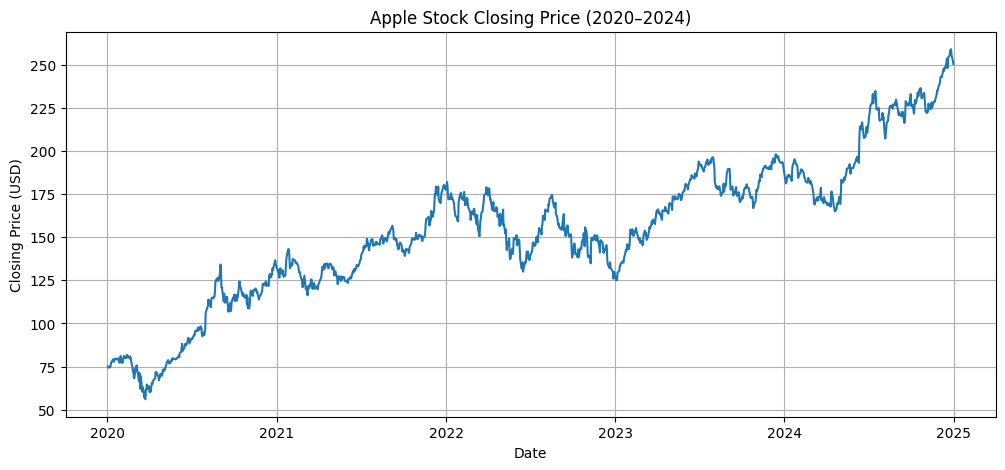

In [21]:
plt.figure(figsize=(12, 5))

plt.plot(data.index, data)

plt.title("Apple Stock Closing Price (2020–2024)")
plt.xlabel("Date")
plt.ylabel("Closing Price (USD)")

plt.grid(True)
plt.show()

In [22]:
print("Starting Price:", round(data.iloc[0], 2))
print("Ending Price:", round(data.iloc[-1], 2))
print("Minimum Price:", round(data.min(), 2))
print("Maximum Price:", round(data.max(), 2))
print("Average Price:", round(data.mean(), 2))

Starting Price: 75.09
Ending Price: 250.42
Minimum Price: 56.09
Maximum Price: 259.02
Average Price: 154.11


In [23]:
# Calculate daily price changes
daily_change = data.diff()

print("Daily Change Statistics:")
display(daily_change.describe())

Daily Change Statistics:


count    1257.000000
mean        0.139485
std         2.700307
min       -10.589996
25%        -1.309998
50%         0.174995
75%         1.669998
max        14.029999
Name: AAPL, dtype: float64

In [24]:
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(data)

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("Number of Lags:", adf_result[2])
print("Number of Observations:", adf_result[3])

print("\nCritical Values:")
for key, value in adf_result[4].items():
    print(f"{key}: {value}")

if adf_result[1] <= 0.05:
    print("\nResult: The data is stationary.")
else:
    print("\nResult: The data is not stationary.")

ADF Statistic: -0.7718815561087223
p-value: 0.8272424531837692
Number of Lags: 0
Number of Observations: 1257

Critical Values:
1%: -3.4355629707955395
5%: -2.863842063387667
10%: -2.567995644141416

Result: The data is not stationary.


In [25]:
data_diff = data.diff().dropna()

print("Original Data Points:", len(data))
print("Differenced Data Points:", len(data_diff))

display(data_diff.head())

Original Data Points: 1258
Differenced Data Points: 1257


Date
2020-01-03   -0.730003
2020-01-06    0.592499
2020-01-07   -0.352493
2020-01-08    1.199997
2020-01-09    1.610001
Name: AAPL, dtype: float64

In [26]:
adf_diff = adfuller(data_diff)

print("ADF Statistic:", adf_diff[0])
print("p-value:", adf_diff[1])

if adf_diff[1] <= 0.05:
    print("\nResult: Differenced data is stationary.")
else:
    print("\nResult: Differenced data is still not stationary.")

ADF Statistic: -35.98016353595328
p-value: 0.0

Result: Differenced data is stationary.


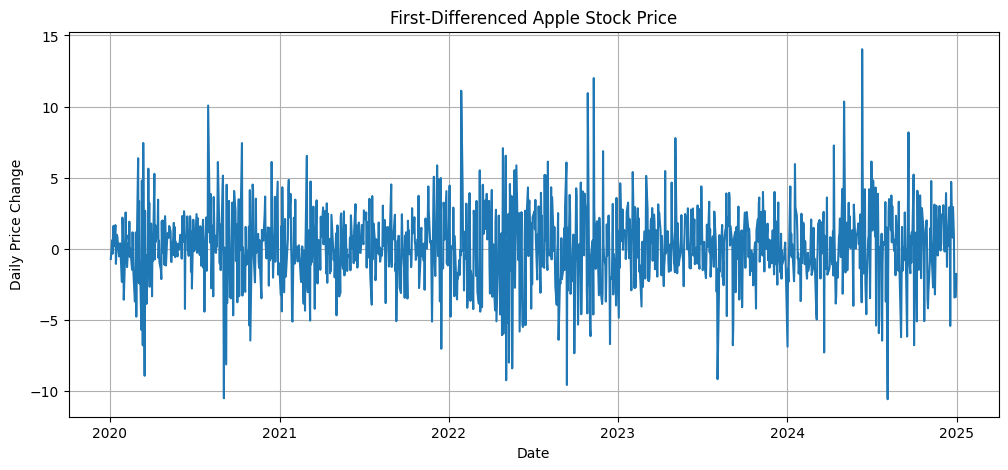

In [27]:
plt.figure(figsize=(12, 5))

plt.plot(data_diff)

plt.title("First-Differenced Apple Stock Price")
plt.xlabel("Date")
plt.ylabel("Daily Price Change")

plt.grid(True)
plt.show()

In [28]:
train_size = int(len(data) * 0.8)

train = data.iloc[:train_size]
test = data.iloc[train_size:]

print("Training Data:", len(train))
print("Testing Data:", len(test))

Training Data: 1006
Testing Data: 252


In [29]:
model = ARIMA(train, order=(5, 1, 0))

model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                   AAPL   No. Observations:                 1006
Model:                 ARIMA(5, 1, 0)   Log Likelihood               -2402.737
Date:                Thu, 13 Aug 2026   AIC                           4817.475
Time:                        01:20:26   BIC                           4846.951
Sample:                             0   HQIC                          4828.675
                               - 1006                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0407      0.027     -1.497      0.134      -0.094       0.013
ar.L2         -0.0222      0.028     -0.803      0.422      -0.077       0.032
ar.L3         -0.0124      0.030     -0.413      0.6

In [30]:
forecast = model_fit.forecast(steps=len(test))

forecast.index = test.index

print("Forecasted Values:")
display(forecast.head())


Forecasted Values:


Date
2024-01-02    192.523784
2024-01-03    192.520316
2024-01-04    192.534846
2024-01-05    192.557348
2024-01-08    192.515876
Name: predicted_mean, dtype: float64

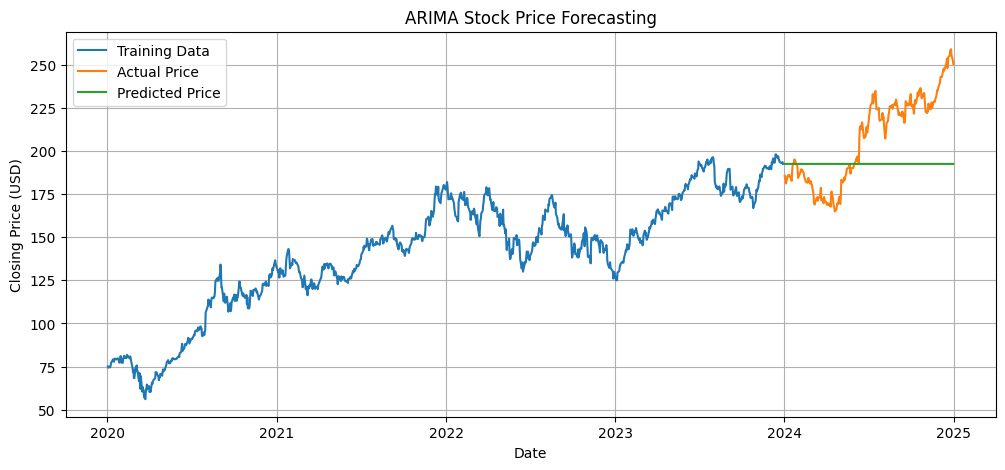

In [31]:
plt.figure(figsize=(12, 5))

plt.plot(train.index, train, label="Training Data")
plt.plot(test.index, test, label="Actual Price")
plt.plot(forecast.index, forecast, label="Predicted Price")

plt.title("ARIMA Stock Price Forecasting")
plt.xlabel("Date")
plt.ylabel("Closing Price (USD)")

plt.legend()
plt.grid(True)
plt.show()

In [32]:
mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))

print("Model Evaluation")
print("-------------------------")
print("Mean Absolute Error (MAE):", round(mae, 2))
print("Root Mean Squared Error (RMSE):", round(rmse, 2))

Model Evaluation
-------------------------
Mean Absolute Error (MAE): 25.01
Root Mean Squared Error (RMSE): 29.39


In [33]:
comparison = pd.DataFrame({
    "Actual Price": test.values,
    "Predicted Price": forecast.values
}, index=test.index)

comparison["Difference"] = (
    comparison["Actual Price"] - comparison["Predicted Price"]
).abs()

display(comparison.head(10))

,Actual Price,Predicted Price,Difference
Date,,,
2024-01-02,185.639999,192.523784,6.883784
2024-01-03,184.250000,192.520316,8.270316
2024-01-04,181.910004,192.534846,10.624843
2024-01-05,181.179993,192.557348,11.377356
2024-01-08,185.559998,192.515876,6.955879
2024-01-09,185.139999,192.516664,7.376664
2024-01-10,186.190002,192.517052,6.327050
2024-01-11,185.589996,192.517955,6.927958
2024-01-12,185.919998,192.519017,6.599019


In [34]:
final_model = ARIMA(data, order=(5, 1, 0))
final_model_fit = final_model.fit()

future_forecast = final_model_fit.forecast(steps=30)

print("Next 30 Trading-Day Forecast:")
display(future_forecast)

Next 30 Trading-Day Forecast:


1258    250.661995
1259    250.761041
1260    250.710640
1261    250.633051
1262    250.608129
1263    250.616249
1264    250.619625
1265    250.618436
1266    250.616733
1267    250.616404
1268    250.616636
1269    250.616722
1270    250.616688
1271    250.616651
1272    250.616648
1273    250.616654
1274    250.616656
1275    250.616655
1276    250.616654
1277    250.616654
1278    250.616654
1279    250.616654
1280    250.616654
1281    250.616654
1282    250.616654
1283    250.616654
1284    250.616654
1285    250.616654
1286    250.616654
1287    250.616654
Name: predicted_mean, dtype: float64

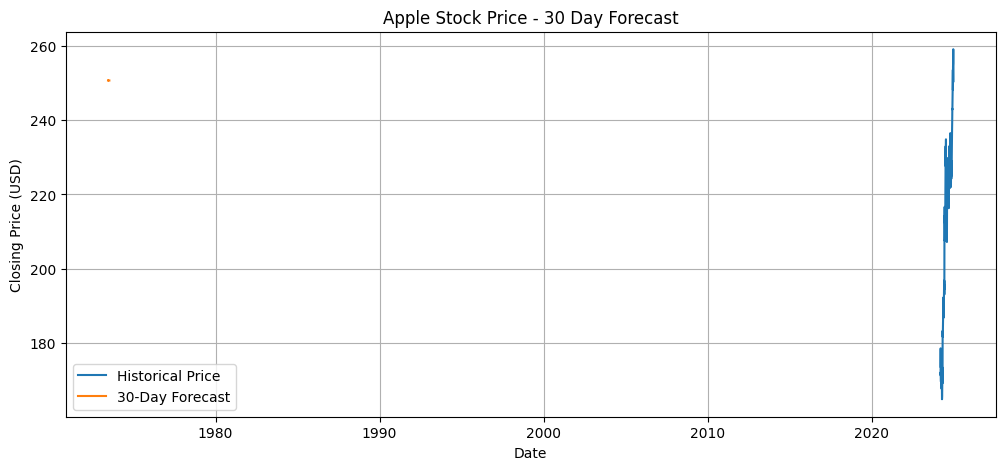

In [35]:
plt.figure(figsize=(12, 5))

plt.plot(data.index[-200:], data.iloc[-200:], label="Historical Price")
plt.plot(future_forecast.index, future_forecast, label="30-Day Forecast")

plt.title("Apple Stock Price - 30 Day Forecast")
plt.xlabel("Date")
plt.ylabel("Closing Price (USD)")

plt.legend()
plt.grid(True)
plt.show()

## Conclusion

In this project, historical Apple stock price data from 2020 to 2024 was analyzed using time series forecasting techniques.

The Augmented Dickey-Fuller (ADF) test was used to examine stationarity, and first-order differencing was applied to make the series suitable for ARIMA modeling.

An ARIMA(5,1,0) model was trained on 80% of the data and evaluated on the remaining 20% using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE).

The model was then trained on the complete dataset to generate a 30-trading-day forecast.

This project provided practical experience in time series analysis, data preprocessing, statistical testing, ARIMA modeling, forecasting, and model evaluation.